In [1]:
#  IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn

In [2]:
#  LOAD DATA
df = pd.read_csv("AirQuality.csv", sep=';')

# remove unwanted columns
df = df.dropna(axis=1, how='all')

# replace -200 with NaN
df = df.replace(-200, np.nan)

# FIX: comma → dot (VERY IMPORTANT)
df = df.replace(',', '.', regex=True)

# convert  numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce') # Changed 'ignore' to 'coerce'
# drop date/time for now
df = df.drop(['Date', 'Time'], axis=1, errors='ignore')
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# drop NaN
df = df.fillna(df.mean())

# Drop any columns that are still entirely NaN after filling (e.g., if their mean was NaN)
df = df.dropna(axis=1, how='all')

print("Final shape:", df.shape)
print("NaN remaining:", df.isnull().sum().sum())

Final shape: (9471, 13)
NaN remaining: 0


In [3]:
# Feature Engineering
target = "CO(GT)"

# lag
df["lag1"] = df[target].shift(1)

# rolling
df["roll3"] = df[target].rolling(3).mean()

df = df.fillna(df.mean())

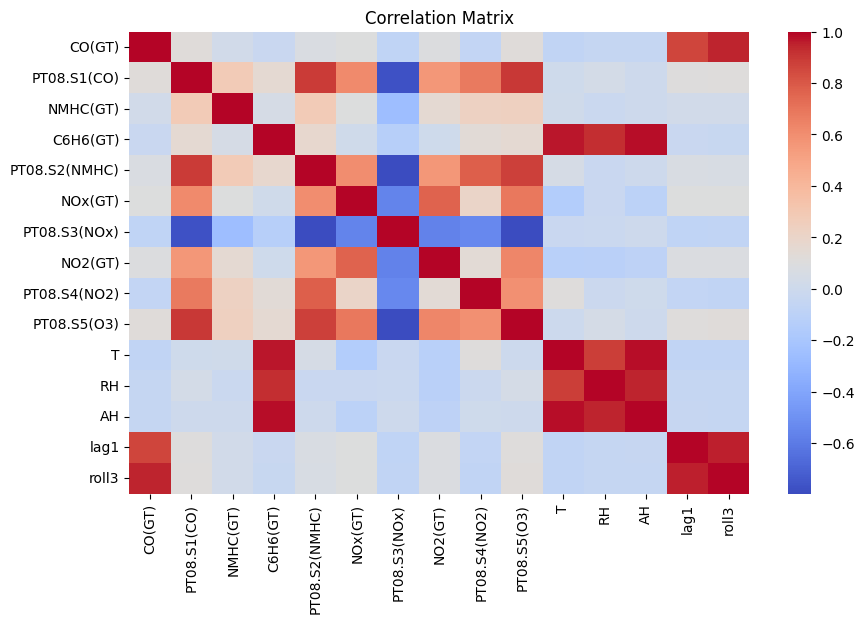

In [4]:
# EDA
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [5]:
px.scatter(df, x=df.columns[0], y=df.columns[1], title="Scatter Plot")

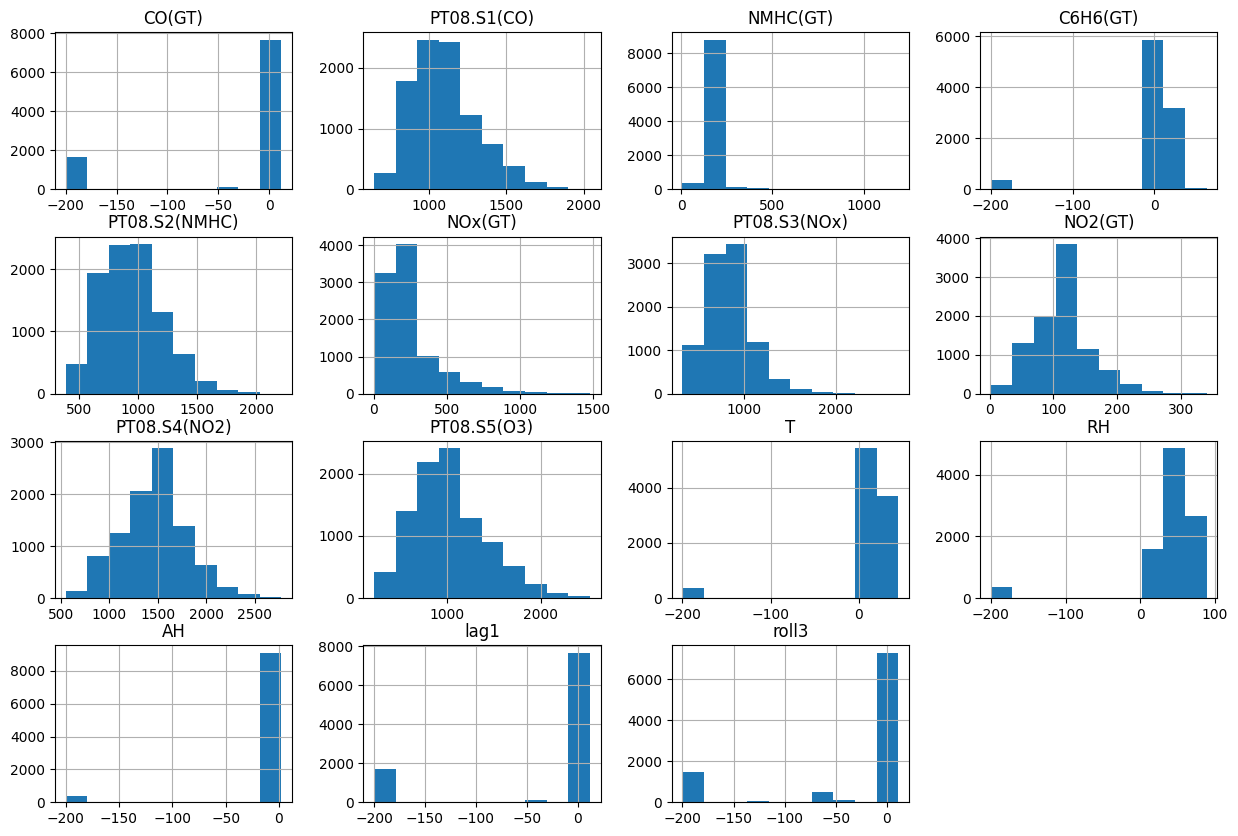

In [6]:
df.hist(figsize=(15,10))
plt.show()

In [7]:
# Feature + Target
X = df.drop(target, axis=1)
y = df[target]

# Drop rows with any NaN values from X and y
# This ensures that X and y are clean before splitting and scaling
initial_rows = X.shape[0]
X = X.dropna()
y = y[X.index] # Align y with the cleaned X

if X.shape[0] < initial_rows:
    print(f"Dropped {initial_rows - X.shape[0]} rows containing NaN values.")

In [8]:
# Time Series Split
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [9]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# Base Models
lr = LinearRegression()
rf = RandomForestRegressor()
xgb = XGBRegressor()

In [11]:
# Cross Validation
cv_scores = cross_val_score(lr, X_train, y_train, cv=5)
print("CV Score:", np.mean(cv_scores))

CV Score: 0.9088741432394167


In [12]:
# Hyperparameter Tuning
params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestRegressor(), params, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [13]:
# Final Train
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))

MSE: 327.95522523390497


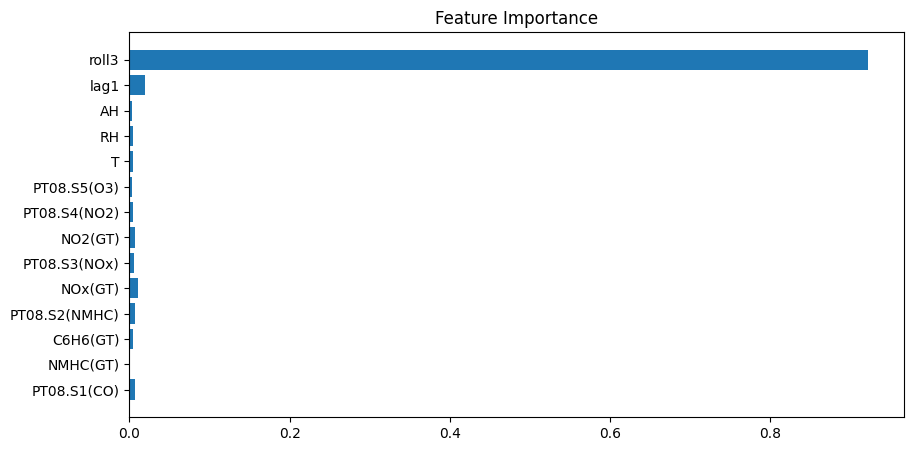

In [14]:
# Fature Importance
importances = best_model.feature_importances_

plt.figure(figsize=(10,5))
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

In [15]:
# DEEP LEARNING (TensorFlow)
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6590.6196 - val_loss: 1244.8684
Epoch 2/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1070.5563 - val_loss: 870.5602
Epoch 3/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 900.9326 - val_loss: 773.3764
Epoch 4/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 788.0712 - val_loss: 686.1965
Epoch 5/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 681.5119 - val_loss: 623.9173
Epoch 6/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 595.5060 - val_loss: 554.4390
Epoch 7/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 542.5081 - val_loss: 524.2722
Epoch 8/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 516.2427 - val_loss: 510.8406
Epoch 9/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 507.6548 - val_loss: 490.0654
Epoch 10/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 501.8681 - val_loss: 488.8406


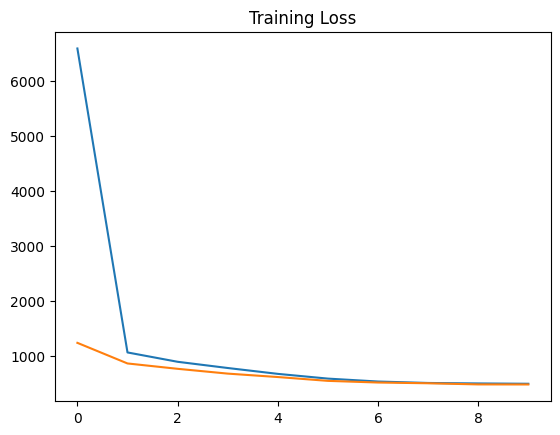

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training Loss")
plt.show()

In [17]:
# PYTORCH MODEL
import torch
import torch.nn as nn

# convert to tensor
X_torch = torch.tensor(X_train, dtype=torch.float32)
y_torch = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

# model
class Net(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model_pt = Net(X_train.shape[1])

# training
optimizer = torch.optim.Adam(model_pt.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for epoch in range(20):
    optimizer.zero_grad()
    output = model_pt(X_torch)
    loss = loss_fn(output, y_torch)
    loss.backward()
    optimizer.step()

print("✅ PyTorch Training Done")

print("PyTorch Training Done")

✅ PyTorch Training Done
PyTorch Training Done


In [18]:
# UNSUPERVISED LEARNING
from sklearn.cluster import KMeans

X_clean = pd.DataFrame(X).fillna(0)

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_clean)

df['cluster'] = clusters


In [19]:
# NLP PART
from sklearn.feature_extraction.text import TfidfVectorizer

texts = [
    "pollution high",
    "clean air",
    "toxic gas"
]

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(texts)

print(X_text.toarray())

[[0.         0.         0.         0.70710678 0.70710678 0.        ]
 [0.70710678 0.70710678 0.         0.         0.         0.        ]
 [0.         0.         0.70710678 0.         0.         0.70710678]]


In [20]:
# SAVE MODELS
import joblib
import torch

# Save ML model
joblib.dump(best_model, "rf_model.pkl")

# Save TensorFlow model
model.save("dl_model.h5")

# Save PyTorch model
torch.save(model_pt.state_dict(), "pytorch_model.pth")

print("✅ All models saved successfully")

✅ All models saved successfully
